# Notebook 1 — Monant full_data · Descriptive Analysis
## claims.csv (4 classes): false, almost false, almost true, true

**Project:** A Multi-Source Benchmark for CVD Health Misinformation Detection  
**Dataset:** `full_data/claims.csv`  
**Goal:** reproduce NB1-style descriptive analysis directly on `full_data`, and export a clean file for NB2.

---
## Section 1 — Installation & Imports

In [26]:
# Uncomment if needed:
# !pip install pandas numpy matplotlib seaborn scikit-learn

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Imports OK')

Imports OK


---
## Section 2 — Data Loading, Thematic Filtering, and 4-Class Labeling
Filtrage thématique: maladies cardiovasculaires + diabète (et termes associés).

In [30]:
import re
import unicodedata

claims_path = Path('full_data/claims.csv')
if not claims_path.exists():
    raise FileNotFoundError(f'File not found: {claims_path}')

claims_raw = pd.read_csv(claims_path, low_memory=False)

# Mapping aligned with NB2
rating_aliases = {
    'false': 'false',
    'mostly-false': 'almost false',
    'almost false': 'almost false',
    'mostly true': 'almost true',
    'mostly-true': 'almost true',
    'almost true': 'almost true',
    'true': 'true',
}
class_order = ['false', 'almost false', 'almost true', 'true']
label_to_id = {c: i for i, c in enumerate(class_order)}

# Thematic keywords: cardio + diabetes (FR + EN)
health_keywords = [
    'cardiovascular', 'cardio', 'heart', 'heart disease', 'cardiac',
    'coronary', 'coronary artery disease', 'artery', 'arterial',
    'vascular', 'blood circulation', 'circulatory system',
    'atherosclerosis', 'stroke', 'heart attack', 'myocardial infarction',
    'arrhythmia', 'tachycardia', 'bradycardia', 'heart failure',
    'angina', 'peripheral artery disease', 'vascular disease',
    'blood pressure', 'hypertension', 'high blood pressure',
    'low blood pressure', 'hypotension', 'systolic', 'diastolic',
    'pulse', 'heart rate', 'circulation', 'blood flow',
    'cholesterol', 'lipid', 'lipids', 'hyperlipidemia',
    'dyslipidemia', 'hdl', 'ldl', 'triglycerides',
    'fat metabolism', 'plaque buildup',
    'metabolic syndrome', 'obesity', 'overweight',
    'body mass index', 'bmi', 'fat', 'adipose tissue',
    'inflammation', 'chronic disease', 'lifestyle disease',
    'nutrition', 'diet', 'exercise', 'physical activity',
    'chronic illness', 'risk factor', 'prevention',
    'screening', 'diagnosis', 'treatment', 'therapy',
    'medication', 'clinical', 'symptom', 'complication',
    'comorbidity', 'mortality', 'morbidity'
]


def normalize_text(x):
    x = '' if pd.isna(x) else str(x)
    x = x.lower()
    x = unicodedata.normalize('NFD', x)
    x = ''.join(ch for ch in x if unicodedata.category(ch) != 'Mn')
    x = re.sub(r'\s+', ' ', x).strip()
    return x


keywords_norm = [normalize_text(k) for k in health_keywords]

# Build searchable text and keep only thematic claims
claims_raw['_search_text'] = (
    claims_raw['name'].fillna('').astype(str) + ' ' +
    claims_raw['statement'].fillna('').astype(str) + ' ' +
    claims_raw['description'].fillna('').astype(str) + ' ' +
    claims_raw['category'].fillna('').astype(str)
)
claims_raw['_search_norm'] = claims_raw['_search_text'].map(normalize_text)

pattern = '|'.join(re.escape(k) for k in sorted(set(keywords_norm), key=len, reverse=True))
mask_theme = claims_raw['_search_norm'].str.contains(pattern, regex=True, na=False)
claims_thematic = claims_raw[mask_theme].copy()

# Save filtered raw CSV for downstream notebook NB2
filtered_raw_path = Path('full_data/claims_cardio_diabete_filtered.csv')
claims_thematic.drop(columns=['_search_text', '_search_norm']).to_csv(filtered_raw_path, index=False)

# 4-class labeling on filtered thematic subset
df_claims = claims_thematic.copy()
df_claims['rating_norm'] = df_claims['rating'].astype(str).str.strip().str.lower()
df_claims['label_name'] = df_claims['rating_norm'].map(rating_aliases)
df_claims = df_claims[df_claims['label_name'].isin(class_order)].copy()
df_claims['label'] = df_claims['label_name'].map(label_to_id).astype(int)

df_claims['text'] = (
    df_claims['name'].fillna('').astype(str) + ' ' +
    df_claims['statement'].fillna('').astype(str) + ' ' +
    df_claims['description'].fillna('').astype(str)
)
df_claims['text'] = df_claims['text'].str.replace(r'\s+', ' ', regex=True).str.strip()
df_claims = df_claims[df_claims['text'].astype(bool)].copy()
df_claims['text_len'] = df_claims['text'].str.len()

print(f'Raw rows (claims.csv): {len(claims_raw)}')
print(f'Thematic rows (cardio+diabetes): {len(claims_thematic)}')
print(f'Filtered raw CSV saved: {filtered_raw_path}')
print(f'Filtered rows with 4-class labels: {len(df_claims)}')
print(df_claims['label_name'].value_counts().reindex(class_order, fill_value=0).to_string())

Raw rows (claims.csv): 3423
Thematic rows (cardio+diabetes): 1075
Filtered raw CSV saved: full_data/claims_cardio_diabete_filtered.csv
Filtered rows with 4-class labels: 645
label_name
false           467
almost false     48
almost true      26
true            104


---
## Section 3 — Data Quality and Class Balance

In [31]:
print('Missing values in raw claims:')
print(claims_raw.isnull().sum().to_string())

class_counts = df_claims['label_name'].value_counts().reindex(class_order, fill_value=0)
class_pct = (100 * class_counts / len(df_claims)).round(2)

print('\nClass distribution:')
print(pd.DataFrame({'count': class_counts, 'pct': class_pct}))

print('\nTop categories:')
print(df_claims['category'].fillna('NA').value_counts().head(10).to_string())

print('\nText length summary:')
print(df_claims['text_len'].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).to_string())

Missing values in raw claims:
id                 0
name            3292
statement          0
description      678
category           0
rating          1054
queries         3292
created_at         0
updated_at         0
_search_text       0
_search_norm       0

Class distribution:
              count    pct
label_name                
false           467  72.40
almost false     48   7.44
almost true      26   4.03
true            104  16.12

Top categories:
category
{medical}                    553
{medical,science}             28
{photos,medical}              15
{media-matters,medical}        7
{animals,medical}              4
{medical,politics}             4
{horrors,medical}              4
{health,medical}               3
{medical,viral-phenomena}      2
{medical,oldwivestales}        2

Text length summary:
count      645.000000
mean      4620.562791
std       3779.315550
min         21.000000
25%        599.000000
50%       4438.000000
75%       6701.000000
90%       9252.600000
ma

---
## Section 4 — Descriptive Visualizations

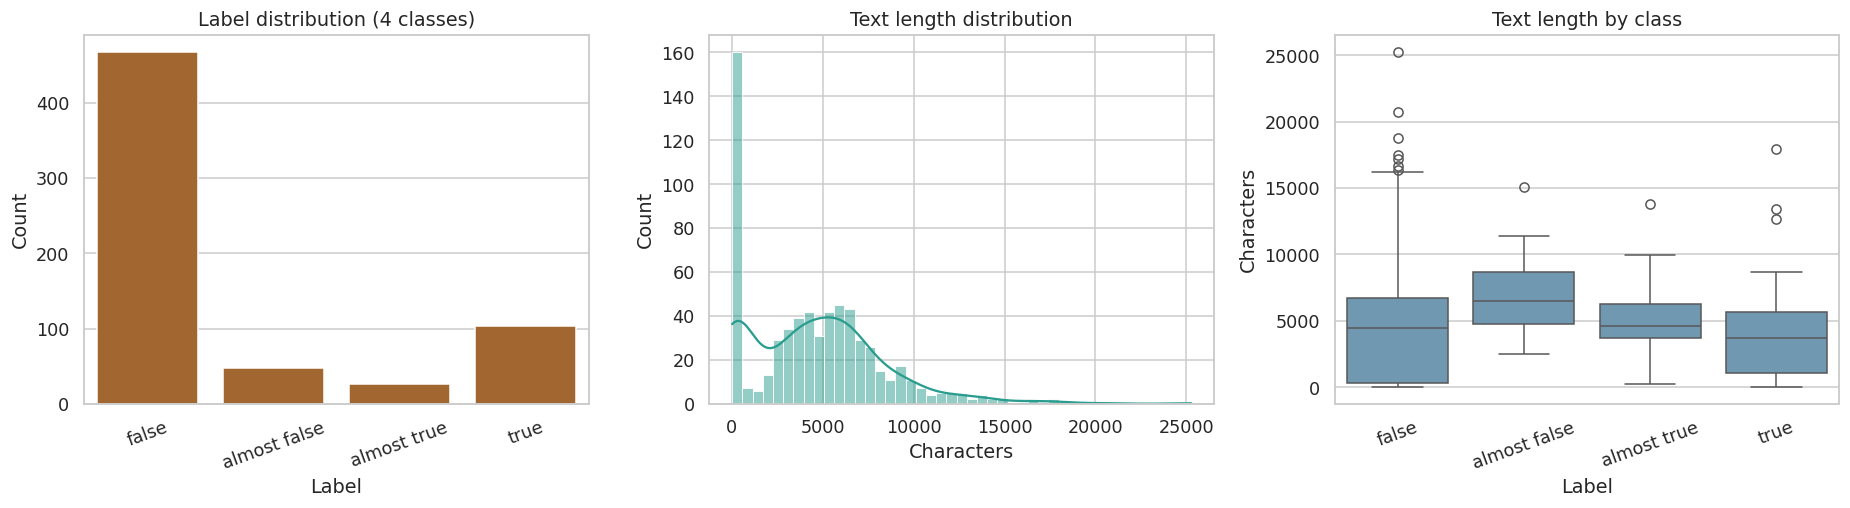

Saved: fig_nb1_claims_4classes_overview.png


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

sns.countplot(data=df_claims, x='label_name', order=class_order, ax=axes[0], color='#b5651d')
axes[0].set_title('Label distribution (4 classes)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

sns.histplot(df_claims['text_len'], bins=45, kde=True, ax=axes[1], color='#2a9d8f')
axes[1].set_title('Text length distribution')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Count')

sns.boxplot(data=df_claims, x='label_name', y='text_len', order=class_order, ax=axes[2], color='#669bbc')
axes[2].set_title('Text length by class')
axes[2].set_xlabel('Label')
axes[2].set_ylabel('Characters')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('fig_nb1_claims_4classes_overview.png', bbox_inches='tight', dpi=130)
plt.show()
print('Saved: fig_nb1_claims_4classes_overview.png')

---
## Section 5 — Lexical Analysis (Top Terms)

Top 20 terms (global):


,term,count
0,covid,1631
1,19,1548
2,vaccine,1208
3,health,1147
4,cancer,1098
5,people,1069
6,disease,851
7,study,797
8,medical,727
9,said,699


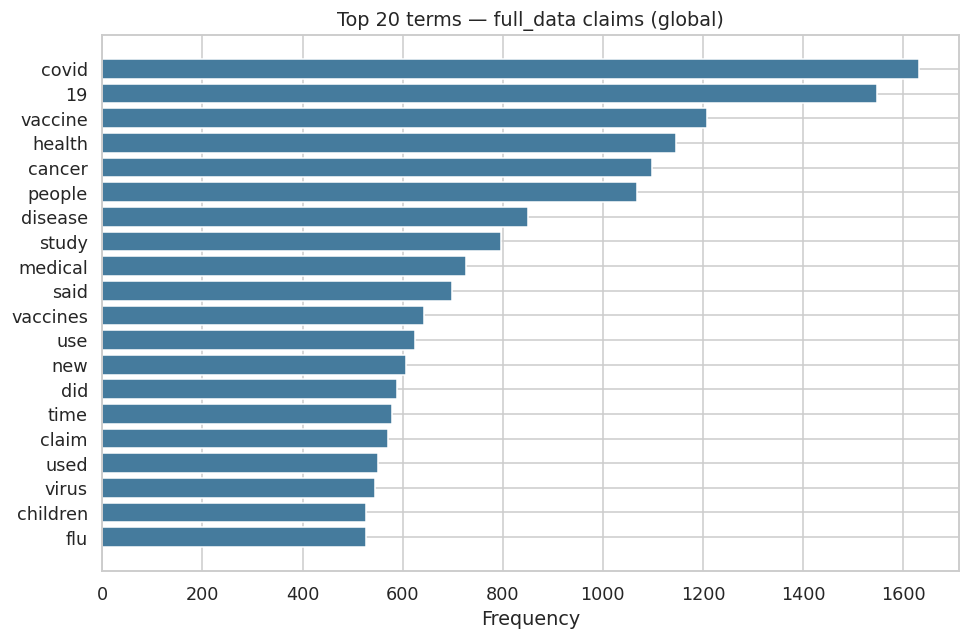

Saved: fig_nb1_top_terms_global.png

Top 10 terms per class:
  - false: covid, 19, vaccine, cancer, people, health, study, vaccines, disease, medical
  - almost false: health, covid, 19, disease, people, study, cancer, vaccine, masks, medical
  - almost true: 19, covid, health, hiv, said, reported, disease, coronavirus, dr, study
  - true: covid, 19, cancer, said, vaccine, disease, health, cases, drug, new


In [33]:
global_vec = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 1),
    min_df=3,
    max_df=0.95,
    max_features=5000
)
X_global = global_vec.fit_transform(df_claims['text'])
freq_global = np.asarray(X_global.sum(axis=0)).ravel()
terms_global = np.array(global_vec.get_feature_names_out())
idx_global = freq_global.argsort()[::-1][:20]

top_terms = pd.DataFrame({
    'term': terms_global[idx_global],
    'count': freq_global[idx_global]
})

print('Top 20 terms (global):')
display(top_terms)

plt.figure(figsize=(9, 6))
plt.barh(top_terms['term'][::-1], top_terms['count'][::-1], color='#457b9d')
plt.title('Top 20 terms — full_data claims (global)')
plt.xlabel('Frequency')
plt.tight_layout()
plt.savefig('fig_nb1_top_terms_global.png', bbox_inches='tight', dpi=130)
plt.show()
print('Saved: fig_nb1_top_terms_global.png')

print('\nTop 10 terms per class:')
for cls in class_order:
    sub = df_claims[df_claims['label_name'] == cls]
    if len(sub) < 2:
        print(f'  - {cls}: not enough samples')
        continue

    vec = CountVectorizer(stop_words='english', ngram_range=(1, 1), min_df=1, max_features=3000)
    Xc = vec.fit_transform(sub['text'])
    freq = np.asarray(Xc.sum(axis=0)).ravel()
    terms = np.array(vec.get_feature_names_out())
    idx = freq.argsort()[::-1][:10]
    top_cls = ', '.join(terms[idx])
    print(f'  - {cls}: {top_cls}')

---
## Section 6 — Export Files for NB2

In [34]:
baseline_ready = df_claims[['id', 'text', 'label_name', 'label', 'rating_norm', 'category']].copy()
baseline_ready.to_csv('full_data_claims_cardio_diabete_baseline_ready_4classes.csv', index=False)

class_stats = (
    df_claims['label_name']
    .value_counts()
    .reindex(class_order, fill_value=0)
    .rename_axis('label_name')
    .reset_index(name='count')
)
class_stats['pct'] = (100 * class_stats['count'] / class_stats['count'].sum()).round(2)
class_stats.to_csv('full_data_claims_cardio_diabete_4classes_stats.csv', index=False)

print('Saved: full_data_claims_cardio_diabete_baseline_ready_4classes.csv')
print(f'Rows: {len(baseline_ready)}')
print('\nSaved: full_data_claims_cardio_diabete_4classes_stats.csv')
print(class_stats.to_string(index=False))

Saved: full_data_claims_cardio_diabete_baseline_ready_4classes.csv
Rows: 645

Saved: full_data_claims_cardio_diabete_4classes_stats.csv
  label_name  count   pct
       false    467 72.40
almost false     48  7.44
 almost true     26  4.03
        true    104 16.12
